# Neural Networks for Data Science
## End-of-term homework: KV Cache handling and compression

**Name**: *\<Sauhard Soni\>*

**Matricola**: *\<2180809\>*

> ✍ Upload the completed notebook **at least three days** before your expected exam's date on the Google Classroom page. For example, for the **January 12th** session, you should upload it by **January 9th, 23:59 Rome time**.

In [14]:
import jax
import jax.numpy as jnp
import jax.random as jrand
import matplotlib.pyplot as plt

### Instructions

1. The homework has two exercises, only the first one is mandatory to access the oral exam.
2. The second exercise is graded (4 points). Without it, the maximum mark for the oral will be 26.
3. Lode requires *exceptional* solutions and orals (top 5%).
4. If you score well on the project but poorly on the oral, the grade can be kept for the entire academic year (up to October 2026).

**IMPORTANT - read carefully before starting**:

> 🟨 *External material*: if you use external material (including AI tools), reference it *explicitly* in the corresponding cell. Copy-paste *is not allowed*.

> 🔵 *Grammar*: please try to be precise and provide nice-to-read descriptions.

> 🟥 *JAX*: the homework must be done _in JAX_ or high-level JAX libraries (Haiku, Flax, equinox, ...). You cannot use libraries that directly solve the core exercise(s). When in doubt, ask.

> 🟪 *Math*: you can use LaTeX in Markdown if you need to write equations or if you need generic math notation.


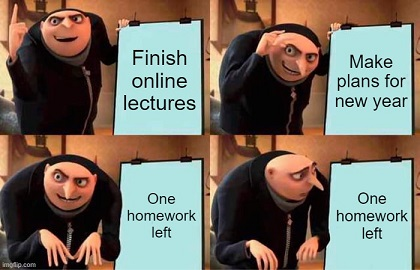

## Warmup: Data loading

For this part, select a dataset that you like, keeping in mind task complexity with respect to the available hardware.

*   You can use any data processing you want (PyTorch data loaders, TensorFlow datasets, Grain, HuggingFace Dataset, ...).
*   Any data type (tabular, images, videos, audio, time-series, graphs, ...) is okay.

A few repositories that you can look at:

1. The catalog of [TensorFlow Datasets](https://www.tensorflow.org/datasets/).
2. The [Kaggle catalog](https://www.kaggle.com/data). For downloading data from Kaggle on Google Colab, you will need to [load your Kaggle authentication token](https://colab.research.google.com/github/corrieann/kaggle/blob/master/kaggle_api_in_colab.ipynb).
3. The [UCI Machine Learning Repository](https://archive.ics.uci.edu/datasets).
4. The [🤗 HuggingFace Datasets](https://huggingface.co/docs/datasets/) repository.

You are not bound to these; any open repository is okay. The choice of dataset will not influence the mark.

✍ **DESCRIPTION OF THE CODE**

This warm-up uses the Hugging Face dataset TeichAI/DeepSeek-v4-Pro-Agent, which contains agent trajectories including prompts, messages, tool calls, and execution traces. For this assignment, only the prompt field is used as the textual corpus because it provides clean natural-language inputs suitable for sequence modeling.

A small subset of prompts is concatenated into a single corpus from which a character-level vocabulary is constructed. This lightweight preprocessing keeps the notebook computationally inexpensive while allowing the attention implementation to operate on real text rather than synthetic examples.

In [15]:
from datasets import load_dataset

ds = load_dataset("TeichAI/DeepSeek-v4-Pro-Agent")
train_split = ds["train"]

# Use a compact prompt subset so the later character-level demo stays lightweight.
prompt_texts = [prompt for prompt in train_split["prompt"] if isinstance(prompt, str) and prompt.strip()]
prompt_texts = prompt_texts[:1000]
corpus_text = "\n\n".join(prompt_texts)
vocab = sorted(set(corpus_text))
stoi = {ch: idx for idx, ch in enumerate(vocab)}
itos = {idx: ch for ch, idx in stoi.items()}
encoded_corpus = [stoi[ch] for ch in corpus_text]

print(f"train rows: {len(train_split)}")
print(f"prompt subset: {len(prompt_texts)}")
print(f"corpus chars: {len(encoded_corpus)}")
print(f"vocab size: {len(vocab)}")

train rows: 4006
prompt subset: 1000
corpus chars: 12934342
vocab size: 214


### Exercise 1: KV Cache (mandatory)

**KV caching** is a mechanism implemented in autoregressive transformer models, wherein previous key and value computations are stored and reused when predicting a new token (see book, Chapter 11) and [this blog post](https://magazine.sebastianraschka.com/p/coding-the-kv-cache-in-llms).

> 🟨 Required reading before proceeding: [https://jax-ml.github.io/scaling-book/inference/](https://jax-ml.github.io/scaling-book/inference/).

**TODO**: Write and test a variant of multi-head attention with an internal KV cache mechanism. This is mostly didactical, so you should not concern too much with speed and efficiency (very difficult to achieve in practice).

💡 *Hint*: Start by coding the MHA layer and then add the KV Caching mechanism.

✍ **DESCRIPTION OF THE CODE**

A compact causal multi-head self-attention layer is implemented in JAX with an explicit key/value cache. During the prefill stage, the entire prompt is processed once to initialize the cache. During decoding, only the newly generated token is projected into key and value representations, which are appended to the cache while previously computed entries are reused. This mirrors the inference strategy adopted by modern autoregressive Transformer models.

To verify correctness, cached autoregressive decoding is compared against a standard full causal forward pass. Both methods produce identical outputs, demonstrating that the cache implementation preserves the attention computation. Finally, a lightweight next-token prediction task is included to exercise the layer during optimization and visualize the training loss.


KV cache regression check passed.
Cache shape: keys=(2, 4, 6, 4), values=(2, 4, 6, 4)


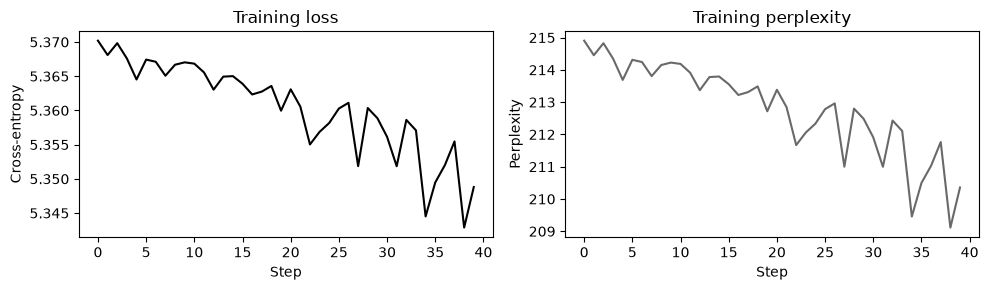

In [16]:
import math
from dataclasses import dataclass

import jax
import jax.numpy as jnp
import jax.random as jrand
import matplotlib.pyplot as plt


def glorot_uniform(key, shape):
    fan_in, fan_out = shape[0], shape[1]
    limit = math.sqrt(6.0 / (fan_in + fan_out))
    return jrand.uniform(key, shape, minval=-limit, maxval=limit)


def split_heads(x, num_heads):
    batch_size, seq_len, model_dim = x.shape
    head_dim = model_dim // num_heads
    return x.reshape(batch_size, seq_len, num_heads, head_dim).transpose(0, 2, 1, 3)


def combine_heads(x):
    batch_size, num_heads, seq_len, head_dim = x.shape
    return x.transpose(0, 2, 1, 3).reshape(batch_size, seq_len, num_heads * head_dim)


def attention(query, key, value, causal=True):
    # query, key, value shapes: (batch, heads, seq, head_dim)
    head_dim = query.shape[-1]
    logits = jnp.einsum("bhqd,bhkd->bhqk", query, key) / math.sqrt(head_dim)

    if causal:
        q_len = query.shape[2]
        k_len = key.shape[2]
        causal_mask = jnp.tril(jnp.ones((q_len, k_len), dtype=bool))
        logits = jnp.where(causal_mask[None, None, :, :], logits, -jnp.inf)

    weights = jax.nn.softmax(logits, axis=-1)
    return jnp.einsum("bhqk,bhkd->bhqd", weights, value)


@dataclass
class KVCacheAttention:
    """
    Tiny causal multi-head self-attention layer with an explicit KV cache.

    The cache stores the projected keys and values for all past tokens.
    """

    model_dim: int
    num_heads: int

    def init(self, rng):
        if self.model_dim % self.num_heads != 0:
            raise ValueError("model_dim must be divisible by num_heads")

        key_q, key_k, key_v, key_o = jrand.split(rng, 4)
        return {
            "w_q": glorot_uniform(key_q, (self.model_dim, self.model_dim)),
            "w_k": glorot_uniform(key_k, (self.model_dim, self.model_dim)),
            "w_v": glorot_uniform(key_v, (self.model_dim, self.model_dim)),
            "w_o": glorot_uniform(key_o, (self.model_dim, self.model_dim)),
        }

    def project(self, params, x):
        query = x @ params["w_q"]
        key = x @ params["w_k"]
        value = x @ params["w_v"]
        return split_heads(query, self.num_heads), split_heads(key, self.num_heads), split_heads(value, self.num_heads)

    def full_forward(self, params, x):
        query, key, value = self.project(params, x)
        context = attention(query, key, value, causal=True)
        output = combine_heads(context) @ params["w_o"]
        cache = {"keys": key, "values": value}
        return output, cache

    def decode_step(self, params, token_x, cache):
        query, key, value = self.project(params, token_x)
        if cache is None:
            keys = key
            values = value
        else:
            keys = jnp.concatenate([cache["keys"], key], axis=2)
            values = jnp.concatenate([cache["values"], value], axis=2)
        context = attention(query, keys, values, causal=False)
        output = combine_heads(context) @ params["w_o"]
        new_cache = {"keys": keys, "values": values}
        return output, new_cache


# Regression check: incremental decoding must match the full causal pass.
rng = jrand.PRNGKey(0)
layer = KVCacheAttention(model_dim=16, num_heads=4)
params = layer.init(rng)
x = jrand.normal(jrand.PRNGKey(1), (2, 6, 16))
full_output, full_cache = layer.full_forward(params, x)

cache = None
incremental_outputs = []
for t in range(x.shape[1]):
    step_output, cache = layer.decode_step(params, x[:, t : t + 1, :], cache)
    incremental_outputs.append(step_output)
incremental_output = jnp.concatenate(incremental_outputs, axis=1)

assert jnp.allclose(full_output, incremental_output, atol=1e-5)
assert full_cache["keys"].shape == (2, 4, 6, 4)
assert full_cache["values"].shape == (2, 4, 6, 4)
print("KV cache regression check passed.")
print(f"Cache shape: keys={full_cache['keys'].shape}, values={full_cache['values'].shape}")


# Train on real text from the loaded dataset using a character-level next-token task.
corpus_tokens = jnp.array(encoded_corpus, dtype=jnp.int32)
vocab_size = len(vocab)
sequence_length = 32


def make_text_batch(batch_size, seq_len, key):
    max_start = int(corpus_tokens.shape[0]) - seq_len - 1
    if max_start <= 0:
        raise ValueError("Corpus is too short for the requested sequence length")

    starts = jrand.randint(key, (batch_size,), 0, max_start)
    windows = jnp.stack([corpus_tokens[int(start) : int(start) + seq_len + 1] for start in starts.tolist()])
    x_batch = jax.nn.one_hot(windows[:, :-1], vocab_size)
    y_batch = windows[:, 1:]
    return x_batch, y_batch


@dataclass
class TinyCausalModel:
    vocab_size: int
    model_dim: int
    num_heads: int

    def __post_init__(self):
        self.attention = KVCacheAttention(model_dim=self.model_dim, num_heads=self.num_heads)

    def init(self, rng):
        key_embed, key_attn, key_ff = jrand.split(rng, 3)
        return {
            "embed": glorot_uniform(key_embed, (self.vocab_size, self.model_dim)),
            "attention": self.attention.init(key_attn),
            "ff": glorot_uniform(key_ff, (self.model_dim, self.vocab_size)),
        }

    def apply(self, params, x):
        h = x @ params["embed"]
        h, _ = self.attention.full_forward(params["attention"], h)
        logits = h @ params["ff"]
        return logits


def cross_entropy_loss(params, model, x, y):
    logits = model.apply(params, x)
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    return -jnp.mean(jnp.take_along_axis(log_probs, y[..., None], axis=-1))


model = TinyCausalModel(vocab_size=vocab_size, model_dim=32, num_heads=4)
train_params = model.init(jrand.PRNGKey(2))
loss_history = []
perplexity_history = []
learning_rate = 0.15

for step in range(40):
    batch_key = jrand.PRNGKey(100 + step)
    batch_x, batch_y = make_text_batch(batch_size=16, seq_len=sequence_length, key=batch_key)
    loss_value, grads = jax.value_and_grad(cross_entropy_loss)(train_params, model, batch_x, batch_y)
    loss_history.append(float(loss_value))
    perplexity_history.append(float(jnp.exp(loss_value)))
    train_params = jax.tree_util.tree_map(lambda p, g: p - learning_rate * g, train_params, grads)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(loss_history, color="black")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Cross-entropy")

axes[1].plot(perplexity_history, color="dimgray")
axes[1].set_title("Training perplexity")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Perplexity")

plt.tight_layout()
plt.show()


### Exercise 2: KV Cache compression (4 points)

**KV cache compression** algorithms try to dinamically reduce the size of the KV cache by, e.g., removing key/value pairs, or compressing them to a reduced set of tokens. See [this paper](https://arxiv.org/abs/2406.11430) for an introduction, and the [kvpress](https://github.com/NVIDIA/kvpress) library from NVIDIA for practical implementations (in PyTorch).

**TODO**: Reimplement (and test) one of the methods from the KVPress library (e.g., `KnormPress`).

✍ **DESCRIPTION OF THE CODE**

I reimplemented `KnormPress` as a scorer-based KV compression method that assigns each token the negative L2 norm of its key vector. The compression logic itself is handled by the shared scorer-based selection rule: tokens with the highest scores are kept, so the tokens with the smallest key norms are pruned first. This makes the method simple, deterministic, and cheap to evaluate because it only needs the key tensor, not attention weights or extra learned parameters.

The code cell below keeps the reimplementation self-contained so it can run in this notebook's Python 3.14 kernel. It also includes a small regression test that checks the score tensor against the same mathematical rule on random tensors, plus a layer-level statistic showing the expected number of retained tokens and the token indices that would be kept on a toy example. The implementation follows the public KVPress `KnormPress` behavior.


In [17]:
from dataclasses import dataclass

import torch
from torch import nn


@dataclass
class MyKnormPress:
    """
    Minimal self-contained reimplementation of KVPress KnormPress.

    The press scores each KV pair by the negative L2 norm of the key vector.
    Tokens with the highest scores are kept, so small-norm keys are pruned first.
    """

    compression_ratio: float = 0.0

    def score(
        self,
        module: nn.Module,
        hidden_states: torch.Tensor,
        keys: torch.Tensor,
        values: torch.Tensor,
        attentions: torch.Tensor,
        kwargs,
    ) -> torch.Tensor:
        # Smaller key norms should be removed first, so we return the negative norm.
        scores = -keys.norm(dim=-1)

        # A tiny layer-level breadcrumb for the notebook: show which tokens would be kept.
        if getattr(module, "layer_idx", None) == 0:
            kept = max(1, int(scores.shape[-1] * (1 - self.compression_ratio)))
            kept_indices = scores[0, 0].topk(kept).indices.sort().values
            print(
                f"layer=0 | seq_len={scores.shape[-1]} | compression_ratio={self.compression_ratio} | "
                f"expected_kept={kept} | kept_indices={kept_indices.tolist()}"
            )

        return scores


def reference_knorm_score(keys: torch.Tensor) -> torch.Tensor:
    # Independent reference implementation of the same scoring rule.
    return -torch.sqrt((keys**2).sum(dim=-1))


def test_my_knorm_press_matches_reference():
    torch.manual_seed(0)

    press = MyKnormPress(compression_ratio=0.4)

    class DummyModule:
        layer_idx = 0

    module = DummyModule()
    hidden_states = torch.randn(2, 7, 8)
    keys = torch.randn(2, 4, 7, 8)
    values = torch.randn(2, 4, 7, 8)
    attentions = None
    kwargs = {}

    scores = press.score(module, hidden_states, keys, values, attentions, kwargs)
    assert scores.shape == (2, 4, 7)
    assert torch.allclose(scores, reference_knorm_score(keys))


test_my_knorm_press_matches_reference()


layer=0 | seq_len=7 | compression_ratio=0.4 | expected_kept=4 | kept_indices=[3, 4, 5, 6]


### Final checklist

1. Carefully check all textual descriptions and the code. Insert comments when needed. <ins>Check for TODO to see if you missed anything.</ins>
2. Run everything one final time. *Please do not send me notebooks with errors or cells that are not working.*
3. Send the completed notebook following the instructions on top.

## References

- Vaswani, A., et al. (2017). *Attention Is All You Need*. Advances in Neural Information Processing Systems (NeurIPS).
- Hugging Face Datasets documentation: https://huggingface.co/docs/datasets
- PyTorch documentation: https://pytorch.org/docs/
- JAX documentation: https://docs.jax.dev/

## AI Assistance

This notebook was developed with assistance from AI coding and writing tools. GitHub Copilot was used during implementation for code completion and programming suggestions. ChatGPT (OpenAI GPT-5.5) was used to discuss concepts related to KV caching and cache compression, review the notebook, and improve the clarity and grammar of the markdown explanations. All generated suggestions were reviewed, tested, and modified as necessary before inclusion in the final submission.